In [29]:
# Install CatBoost
!pip install catboost

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import time

In [31]:
X      = pd.read_csv('/content/final_cleaned_data.csv')
y_crop = pd.read_csv('/content/crop_labels.csv').squeeze().values
y_fert = pd.read_csv('/content/fert_labels.csv').squeeze().values

print("Data loaded. Shape:", X.shape)
print(f"Crop classes: {len(np.unique(y_crop))}, Fert classes: {len(np.unique(y_fert))}")

Data loaded. Shape: (3100, 13)
Crop classes: 31, Fert classes: 10


In [32]:
# =============================================================================
# SECTION 1 — TRAIN-TEST SPLIT
# =============================================================================


RANDOM_STATE = 42
TEST_SIZE     = 0.2

indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_crop          # stratify on primary target (31 balanced classes)
)

X_train      = X.iloc[train_idx].reset_index(drop=True)
X_test       = X.iloc[test_idx].reset_index(drop=True)
y_crop_train = y_crop[train_idx]
y_crop_test  = y_crop[test_idx]
y_fert_train = y_fert[train_idx]
y_fert_test  = y_fert[test_idx]

In [33]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"y_crop_train: {y_crop_train.shape}, y_fert_train: {y_fert_train.shape}")

# Verify alignment — every index should only appear in one split
assert len(set(train_idx) & set(test_idx)) == 0, "Index leak between splits!"
print("✓ No index leakage between train/test splits.")

Train: (2480, 13), Test: (620, 13)
y_crop_train: (2480,), y_fert_train: (2480,)
✓ No index leakage between train/test splits.


In [34]:
# =============================================================================
# SECTION 2 — METRIC HELPERS
# =============================================================================

from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, model_name,
                         target_name="Crop", verbose=True, cv_folds=5):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    acc       = accuracy_score(y_te, y_pred)
    f1_mac    = f1_score(y_te, y_pred, average='macro',    zero_division=0)
    f1_wt     = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec_mac  = precision_score(y_te, y_pred, average='macro',    zero_division=0)
    prec_wt   = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec_mac   = recall_score(y_te, y_pred, average='macro',    zero_division=0)
    rec_wt    = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    # Cross-validation on training data (macro F1)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

    # AUC — for ALL class counts (OVR handles high cardinality)
    auc = np.nan
    if hasattr(model, 'predict_proba'):
        try:
            y_prob = model.predict_proba(X_te)
            auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan

    # Save confusion matrix plot
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax, colorbar=False)
    ax.set_title(f"{model_name} — {target_name}")
    plt.tight_layout()
    plt.savefig(f"output/cm_{model_name}_{target_name}.png", dpi=120, bbox_inches='tight')
    plt.close()

    result = {
        'Model':        model_name,
        'Target':       target_name,
        'Accuracy':     round(acc,      4),
        'Precision_Mac':round(prec_mac, 4),
        'Precision_Wt': round(prec_wt,  4),
        'Recall_Mac':   round(rec_mac,  4),
        'Recall_Wt':    round(rec_wt,   4),
        'F1_Macro':     round(f1_mac,   4),
        'F1_Weighted':  round(f1_wt,    4),
        'AUC_OVR':      round(auc, 4) if not np.isnan(auc) else 'N/A',
        'CV_F1_Mean':   round(cv_mean,  4),
        'CV_F1_Std':    round(cv_std,   4),
        'Train_Time':   round(elapsed,  2),
    }

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {model_name} → {target_name}")
        print(f"  Accuracy:        {acc:.4f}")
        print(f"  Precision (mac): {prec_mac:.4f}  |  Weighted: {prec_wt:.4f}")
        print(f"  Recall    (mac): {rec_mac:.4f}  |  Weighted: {rec_wt:.4f}")
        print(f"  F1        (mac): {f1_mac:.4f}  |  Weighted: {f1_wt:.4f}")
        print(f"  AUC (OVR):       {auc if not np.isnan(auc) else 'N/A'}")
        print(f"  CV F1 (5-fold):  {cv_mean:.4f} ± {cv_std:.4f}")
        print(f"  Train time:      {elapsed:.2f}s")

    return result, model, y_pred

all_results = []

In [35]:
# =============================================================================
# SECTION 3 — MODEL DEFINITIONS
# =============================================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 3A. Random Forest ─────────────────────────────────────────────────────────
rf_crop = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_fert = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ── 3B. SVM (RBF kernel — paper uses SVR RBF; here SVC for classification) ───
svm_crop = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,       # needed for AUC and stacking
    random_state=RANDOM_STATE
)
svm_fert = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=RANDOM_STATE
)

# ── 3C. XGBoost ───────────────────────────────────────────────────────────────
n_crop = len(np.unique(y_crop_train))
n_fert = len(np.unique(y_fert_train))

xgb_crop = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_fert = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ── 3D. AdaBoost ─────────────────────────────────────────────────────────────
# Paper: base estimator = RF(100), n_estimators=10, lr=0.05
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_crop = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    algorithm='SAMME'
)
ada_fert = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    algorithm='SAMME'
)

# ── 3E. Gradient Boosting ─────────────────────────────────────────────────────
gb_crop = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb_fert = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)

# ── 3F. CatBoost ──────────────────────────────────────────────────────────────
cat_crop = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=RANDOM_STATE,
    verbose=0
)
cat_fert = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=RANDOM_STATE,
    verbose=0
)

print("✓ All base models defined.")

✓ All base models defined.


In [36]:
import os
os.makedirs("output", exist_ok=True)

# =============================================================================
# SECTION 4 — TRAIN & EVALUATE BASE MODELS
# =============================================================================

targets = [
    ('Crop',        y_crop_train, y_crop_test),
    ('Fertilizer',  y_fert_train, y_fert_test),
]

base_model_pairs = {
    'RandomForest':     (rf_crop,  rf_fert),
    'SVM_RBF':          (svm_crop, svm_fert),
    'XGBoost':          (xgb_crop, xgb_fert),
    'AdaBoost':         (ada_crop, ada_fert),
    'GradientBoosting': (gb_crop,  gb_fert),
    'CatBoost':         (cat_crop, cat_fert),
}


for model_name, (m_crop, m_fert) in base_model_pairs.items():
    for target_name, y_tr, y_te in targets:
        model   = m_crop if target_name == 'Crop' else m_fert
        X_tr_in = X_train_sc if model_name == 'SVM_RBF' else X_train.values
        X_te_in = X_test_sc  if model_name == 'SVM_RBF' else X_test.values

        res, fitted_m, y_pred = evaluate_classifier(
            model, X_tr_in, y_tr, X_te_in, y_te,
            model_name=model_name, target_name=target_name
        )
        all_results.append(res)


  RandomForest → Crop
  Accuracy:        0.5935
  Precision (mac): 0.5942  |  Weighted: 0.5942
  Recall    (mac): 0.5935  |  Weighted: 0.5935
  F1        (mac): 0.5858  |  Weighted: 0.5858
  AUC (OVR):       0.9648911290322582
  CV F1 (5-fold):  0.6165 ± 0.0059
  Train time:      3.75s

  RandomForest → Fertilizer
  Accuracy:        0.9500
  Precision (mac): 0.9225  |  Weighted: 0.9529
  Recall    (mac): 0.9683  |  Weighted: 0.9500
  F1        (mac): 0.9423  |  Weighted: 0.9500
  AUC (OVR):       0.9895808317905918
  CV F1 (5-fold):  0.9267 ± 0.0264
  Train time:      2.75s

  SVM_RBF → Crop
  Accuracy:        0.4597
  Precision (mac): 0.4700  |  Weighted: 0.4700
  Recall    (mac): 0.4597  |  Weighted: 0.4597
  F1        (mac): 0.4404  |  Weighted: 0.4404
  AUC (OVR):       0.9290967741935483
  CV F1 (5-fold):  0.4436 ± 0.0068
  Train time:      1.84s

  SVM_RBF → Fertilizer
  Accuracy:        0.7403
  Precision (mac): 0.7542  |  Weighted: 0.7651
  Recall    (mac): 0.5653  |  Weighted

In [37]:
# =============================================================================
# SECTION 5 — RESULTS SUMMARY
# =============================================================================

results_df = pd.DataFrame(all_results)

print("\n" + "="*90)
print("FULL RESULTS SUMMARY")
print("="*90)

crop_cols = ['Model', 'Accuracy', 'Precision_Mac', 'Recall_Mac', 'F1_Macro',
             'F1_Weighted', 'AUC_OVR', 'CV_F1_Mean', 'CV_F1_Std', 'Train_Time']

fert_cols = ['Model', 'Accuracy', 'Precision_Mac', 'Precision_Wt',
             'Recall_Mac', 'Recall_Wt', 'F1_Macro', 'F1_Weighted',
             'AUC_OVR', 'CV_F1_Mean', 'CV_F1_Std', 'Train_Time']

for target, cols in [('Crop', crop_cols), ('Fertilizer', fert_cols)]:
    sub = results_df[results_df['Target'] == target].sort_values(
        'F1_Macro', ascending=False
    ).reset_index(drop=True)

    print(f"\n── Target: {target} ──")
    print(f"  Note: {'Balanced (31 classes × ~100 each) — Macro F1 is reliable.' if target == 'Crop' else 'Imbalanced — prioritise Macro metrics over Weighted.'}")
    print(sub[cols].to_string(index=False))

    # Per-target best model callout
    best = sub.iloc[0]
    print(f"\n  ★ Best {target} model: {best['Model']}"
          f"  |  F1_Macro: {best['F1_Macro']}"
          f"  |  CV: {best['CV_F1_Mean']} ± {best['CV_F1_Std']}")

# Cross-target comparison: which model family wins both tasks?
print("\n" + "="*90)
print("CROSS-TARGET MODEL COMPARISON (F1_Macro)")
print("="*90)
pivot = results_df.pivot_table(
    index='Model', columns='Target', values='F1_Macro'
).round(4)
pivot['Mean_F1'] = pivot.mean(axis=1)
pivot = pivot.sort_values('Mean_F1', ascending=False)
print(pivot.to_string())

# Save everything
results_df.to_csv('output/model_comparison_results.csv', index=False)
pivot.to_csv('output/model_comparison_pivot.csv')
print("\n✓ Results saved to output/model_comparison_results.csv")
print("✓ Pivot saved    to output/model_comparison_pivot.csv")




FULL RESULTS SUMMARY

── Target: Crop ──
  Note: Balanced (31 classes × ~100 each) — Macro F1 is reliable.
           Model  Accuracy  Precision_Mac  Recall_Mac  F1_Macro  F1_Weighted  AUC_OVR  CV_F1_Mean  CV_F1_Std  Train_Time
        CatBoost    0.6113         0.6170      0.6113    0.6087       0.6087   0.9710      0.6163     0.0163       34.44
GradientBoosting    0.6065         0.6174      0.6065    0.6056       0.6056   0.9620      0.6001     0.0123       51.00
         XGBoost    0.5935         0.5984      0.5935    0.5915       0.5915   0.9685      0.6234     0.0185        9.05
    RandomForest    0.5935         0.5942      0.5935    0.5858       0.5858   0.9649      0.6165     0.0059        3.75
         SVM_RBF    0.4597         0.4700      0.4597    0.4404       0.4404   0.9291      0.4436     0.0068        1.84
        AdaBoost    0.0952         0.0407      0.0952    0.0462       0.0462   0.7477      0.0419     0.0046        0.66

  ★ Best Crop model: CatBoost  |  F1_Macro: 

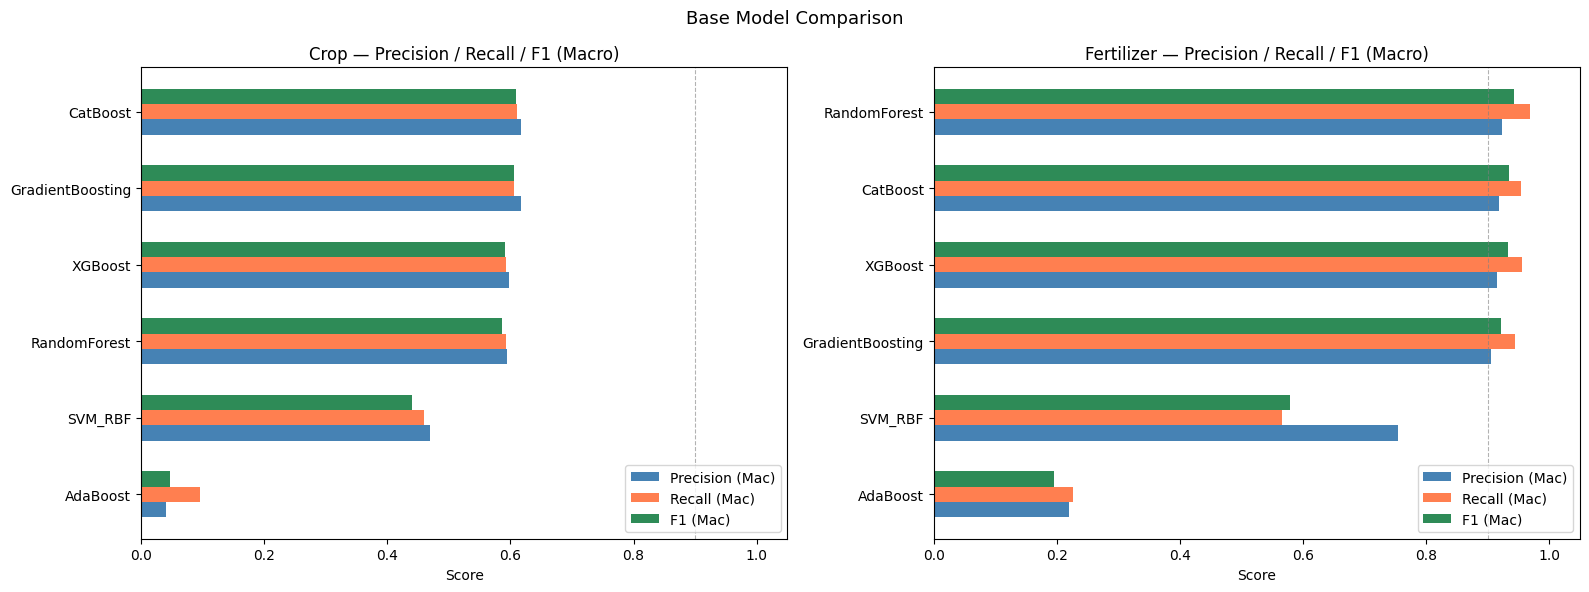

✓ Bar chart saved to output/model_comparison_bar.png


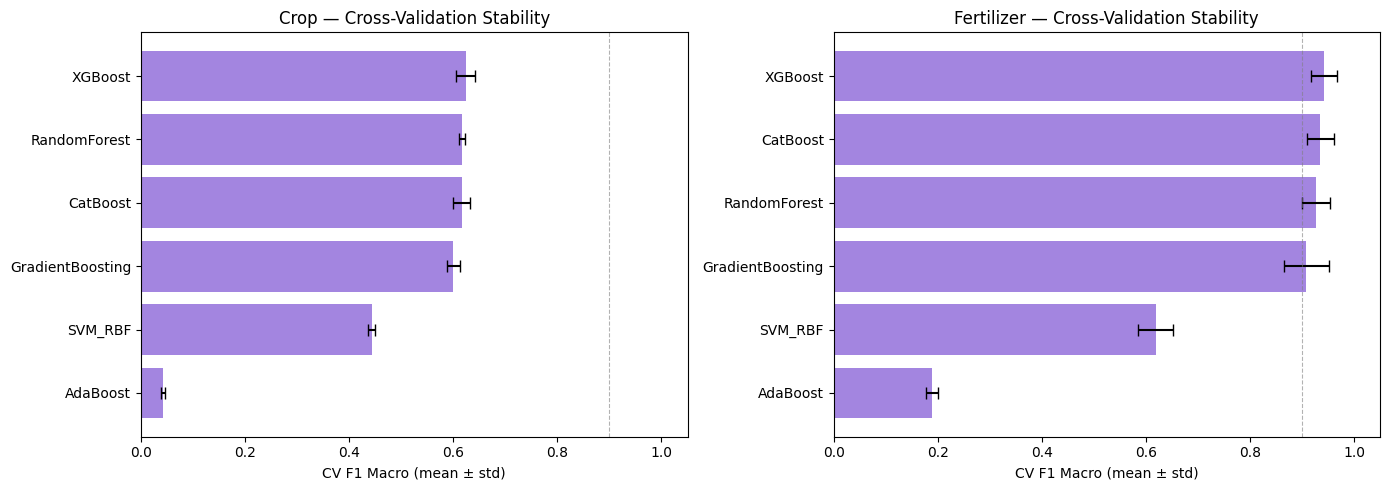

✓ CV stability chart saved to output/cv_stability.png


In [38]:
# =============================================================================
# SECTION 6 — VISUALISATIONS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target in zip(axes, ['Crop', 'Fertilizer']):
    sub = results_df[results_df['Target'] == target].sort_values('F1_Macro')
    models = sub['Model']
    x = np.arange(len(models))
    width = 0.2

    ax.barh(x - width,   sub['Precision_Mac'], width, label='Precision (Mac)', color='steelblue')
    ax.barh(x,           sub['Recall_Mac'],    width, label='Recall (Mac)',    color='coral')
    ax.barh(x + width,   sub['F1_Macro'],      width, label='F1 (Mac)',        color='seagreen')

    ax.set_yticks(x)
    ax.set_yticklabels(models)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Score')
    ax.set_title(f'{target} — Precision / Recall / F1 (Macro)')
    ax.legend(loc='lower right')
    ax.axvline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Base Model Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('output/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bar chart saved to output/model_comparison_bar.png")

# CV stability plot (mean ± std)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, ['Crop', 'Fertilizer']):
    sub = results_df[results_df['Target'] == target].sort_values('CV_F1_Mean')
    ax.barh(sub['Model'], sub['CV_F1_Mean'], xerr=sub['CV_F1_Std'],
            color='mediumpurple', ecolor='black', capsize=4, alpha=0.85)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('CV F1 Macro (mean ± std)')
    ax.set_title(f'{target} — Cross-Validation Stability')
    ax.axvline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('output/cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ CV stability chart saved to output/cv_stability.png")